# SplitWise AI - Expense Analysis

Interactive exploration of itemized expenses extracted from Splitwise.

**Prerequisites:** Run `python extract_expenses.py` first to populate `data/expenses_raw.json`.

In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load Data

In [2]:
DATA_DIR = Path("data")

with open(DATA_DIR / "expenses_raw.json") as f:
    raw_data = json.load(f)

print(f"Loaded {len(raw_data)} expenses")

Loaded 146 expenses


## Build DataFrames

In [3]:
# Expense-level DataFrame
expenses_df = pd.DataFrame([
    {
        "expense_id": e["expense_id"],
        "description": e["description"],
        "cost": e["cost"],
        "date": e["date"],
        "payer": e.get("payer"),
        "num_users": e.get("num_users", 0),
        "num_items": e.get("num_items", 0),
        "group_id": e.get("group_id"),
    }
    for e in raw_data
])
expenses_df["date"] = pd.to_datetime(expenses_df["date"])
expenses_df["month"] = expenses_df["date"].dt.to_period("M")

print(f"Expenses: {len(expenses_df)}")
print(f"Total spend: ${expenses_df['cost'].sum():,.2f}")
print(f"Date range: {expenses_df['date'].min().date()} to {expenses_df['date'].max().date()}")
expenses_df.head()

Expenses: 146
Total spend: $7,240.03
Date range: 2025-04-29 to 2026-01-24


/var/folders/2m/g842w9vn3kg24rrnx3w1lgn00000gn/T/ipykernel_46042/3878255320.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  expenses_df["month"] = expenses_df["date"].dt.to_period("M")


,expense_id,description,cost,date,payer,num_users,num_items,group_id,month
0,4274572903,dollar tree 01/23,12.24,2026-01-24 19:45:38+00:00,Saichandu Juluri,9,5,53885029,2026-01
1,4274569056,costco 01/20,58.47,2026-01-24 19:42:47+00:00,Puneet,9,5,53885029,2026-01
2,4274566060,aldi 01/20,19.08,2026-01-24 19:40:35+00:00,Akula Dhanush,9,6,53885029,2026-01
3,4274559882,aldi 01/19,52.14,2026-01-24 19:36:04+00:00,Satwik Reddy Sripathi,9,15,53885029,2026-01
4,4274555095,costco 01/17,35.53,2026-01-24 19:32:31+00:00,Pranav Kompally,9,4,53885029,2026-01


In [4]:
# Item-level DataFrame
items = []
for e in raw_data:
    if not e.get("item_data"):
        continue
    for item in e["item_data"]:
        name = item.get("name", item.get("item_name", ""))
        price = float(item.get("price", item.get("item_price", 0)))
        members_dict = item.get("members", {})
        if isinstance(members_dict, dict):
            selected = [m for m, s in members_dict.items() if s]
        elif isinstance(members_dict, list):
            selected = members_dict
        else:
            selected = []
        per_member = price / len(selected) if selected else 0
        items.append({
            "expense_id": e["expense_id"],
            "expense_date": e["date"],
            "description": e["description"],
            "item_name": name,
            "item_price": price,
            "num_members": len(selected),
            "members": selected,
            "per_member_cost": round(per_member, 2),
        })

items_df = pd.DataFrame(items)
if not items_df.empty:
    items_df["expense_date"] = pd.to_datetime(items_df["expense_date"])

print(f"Total items: {len(items_df)}")
items_df.head()

Total items: 992


,expense_id,expense_date,description,item_name,item_price,num_members,members,per_member_cost
0,4274572903,2026-01-24 19:45:38+00:00,dollar tree 01/23,Paper Towel,1.50,9,"[Saichandu, Puneet, Yadalla, Saidheeraj, Akula...",0.17
1,4274572903,2026-01-24 19:45:38+00:00,dollar tree 01/23,Alum Foil,5.25,9,"[Saichandu, Puneet, Yadalla, Saidheeraj, Akula...",0.58
2,4274572903,2026-01-24 19:45:38+00:00,dollar tree 01/23,Alum Foil R,1.75,9,"[Saichandu, Puneet, Yadalla, Saidheeraj, Akula...",0.19
3,4274572903,2026-01-24 19:45:38+00:00,dollar tree 01/23,Snickers,2.50,2,"[Yadalla, Akula]",1.25
4,4274572903,2026-01-24 19:45:38+00:00,dollar tree 01/23,tax,1.24,9,"[Saichandu, Puneet, Yadalla, Saidheeraj, Akula...",0.14


## Spending by Member

/var/folders/2m/g842w9vn3kg24rrnx3w1lgn00000gn/T/ipykernel_46042/1122744287.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=member_df, x="member", y="total_owed", ax=ax, palette="YlOrBr")


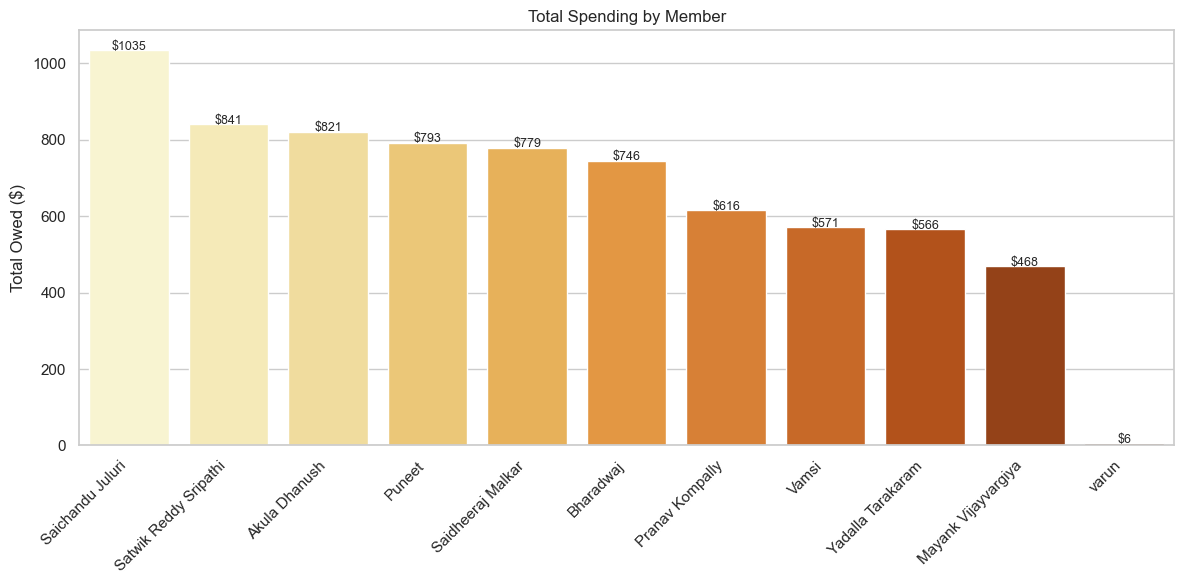

In [5]:
# Total owed per member
member_totals = defaultdict(float)
for e in raw_data:
    for member, amount in e.get("splits", {}).items():
        member_totals[member] += amount

member_df = pd.DataFrame(
    sorted(member_totals.items(), key=lambda x: x[1], reverse=True),
    columns=["member", "total_owed"]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=member_df, x="member", y="total_owed", ax=ax, palette="YlOrBr")
ax.set_title("Total Spending by Member")
ax.set_ylabel("Total Owed ($)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
for i, row in member_df.iterrows():
    ax.text(i, row["total_owed"] + 1, f"${row['total_owed']:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Monthly Spending Trends

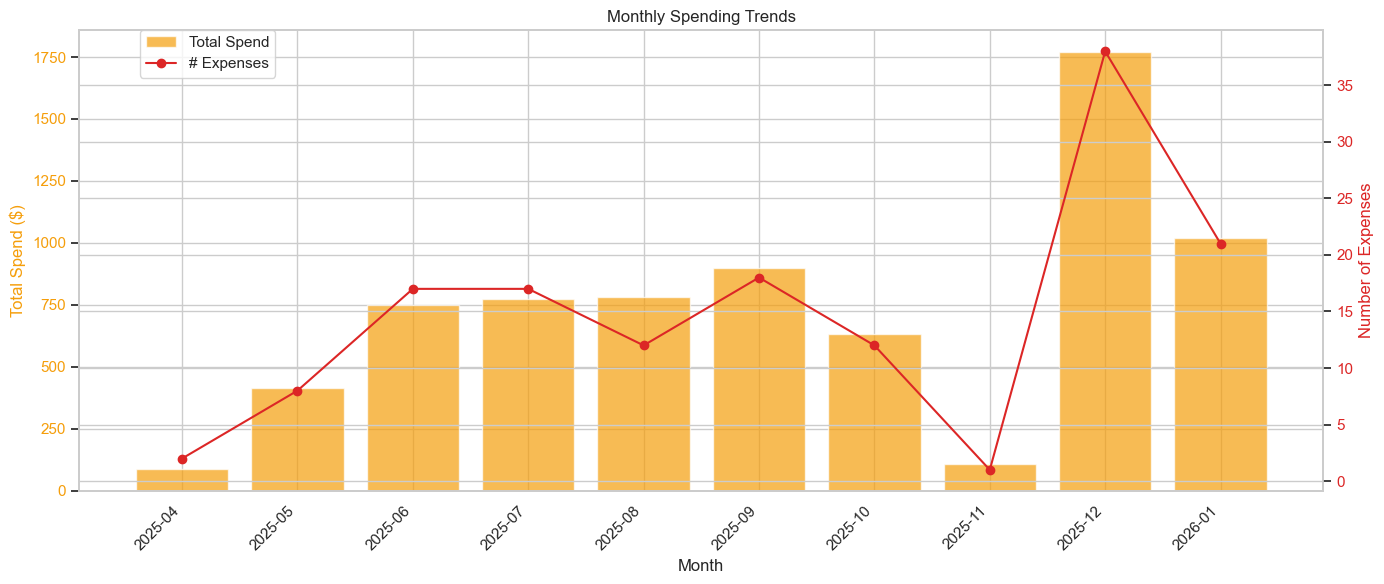

In [6]:
monthly = expenses_df.groupby("month").agg(
    count=("expense_id", "count"),
    total=("cost", "sum"),
).reset_index()
monthly["month_str"] = monthly["month"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(monthly["month_str"], monthly["total"], color="#f59e0b", alpha=0.7, label="Total Spend")
ax1.set_ylabel("Total Spend ($)", color="#f59e0b")
ax1.set_xlabel("Month")
ax1.tick_params(axis="y", labelcolor="#f59e0b")
plt.xticks(rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(monthly["month_str"], monthly["count"], color="#dc2626", marker="o", label="# Expenses")
ax2.set_ylabel("Number of Expenses", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")

ax1.set_title("Monthly Spending Trends")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

## Item Price Distribution

/var/folders/2m/g842w9vn3kg24rrnx3w1lgn00000gn/T/ipykernel_46042/1805048053.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=items_df, x="num_members", y="item_price", ax=axes[1], palette="YlOrBr")


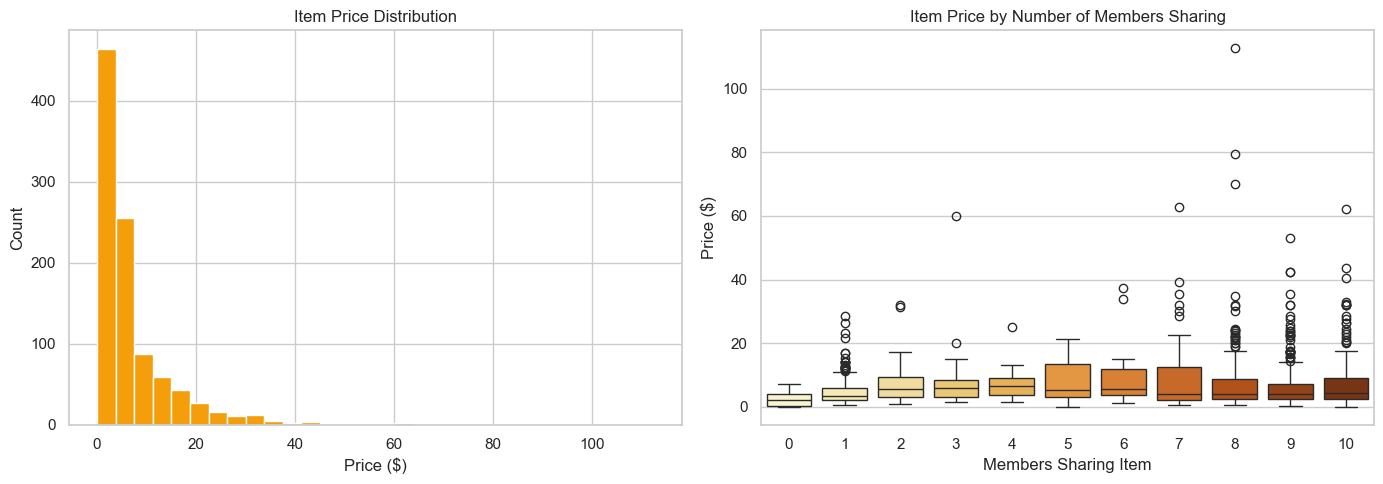

In [7]:
if not items_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(items_df["item_price"], bins=30, color="#f59e0b", edgecolor="white")
    axes[0].set_title("Item Price Distribution")
    axes[0].set_xlabel("Price ($)")
    axes[0].set_ylabel("Count")

    # Box plot by number of members sharing
    sns.boxplot(data=items_df, x="num_members", y="item_price", ax=axes[1], palette="YlOrBr")
    axes[1].set_title("Item Price by Number of Members Sharing")
    axes[1].set_xlabel("Members Sharing Item")
    axes[1].set_ylabel("Price ($)")

    plt.tight_layout()
    plt.show()
else:
    print("No item data available.")

## Member Participation Heatmap

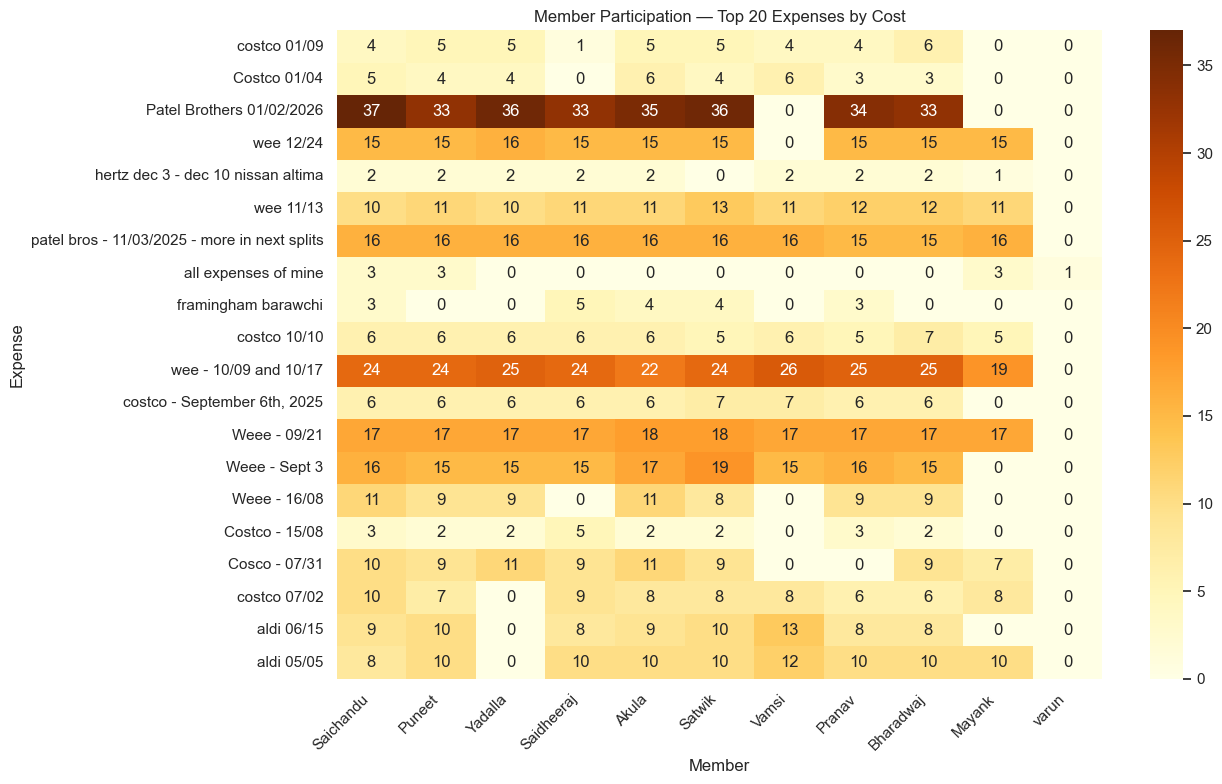

In [8]:
if not items_df.empty:
    # Build member x expense participation matrix
    all_members = set()
    for members_list in items_df["members"]:
        all_members.update(members_list)
    all_members = sorted(all_members)

    # Group by expense description and count items per member
    expense_member_counts = defaultdict(lambda: defaultdict(int))
    for _, row in items_df.iterrows():
        desc = row["description"]
        for m in row["members"]:
            expense_member_counts[desc][m] += 1

    heatmap_df = pd.DataFrame(expense_member_counts).T.fillna(0)
    # Only show if manageable size
    if len(heatmap_df) <= 30:
        fig, ax = plt.subplots(figsize=(max(12, len(all_members) * 1.2), max(6, len(heatmap_df) * 0.4)))
        sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="YlOrBr", ax=ax)
        ax.set_title("Member Participation per Expense (item count)")
        ax.set_ylabel("Expense")
        ax.set_xlabel("Member")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        # Too many expenses — show top 20 by cost
        top_expenses = expenses_df.nlargest(20, "cost")["description"].values
        heatmap_filtered = heatmap_df.loc[heatmap_df.index.isin(top_expenses)]
        fig, ax = plt.subplots(figsize=(max(12, len(all_members) * 1.2), 8))
        sns.heatmap(heatmap_filtered, annot=True, fmt=".0f", cmap="YlOrBr", ax=ax)
        ax.set_title("Member Participation — Top 20 Expenses by Cost")
        ax.set_ylabel("Expense")
        ax.set_xlabel("Member")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No item data available.")

## Top Items by Price

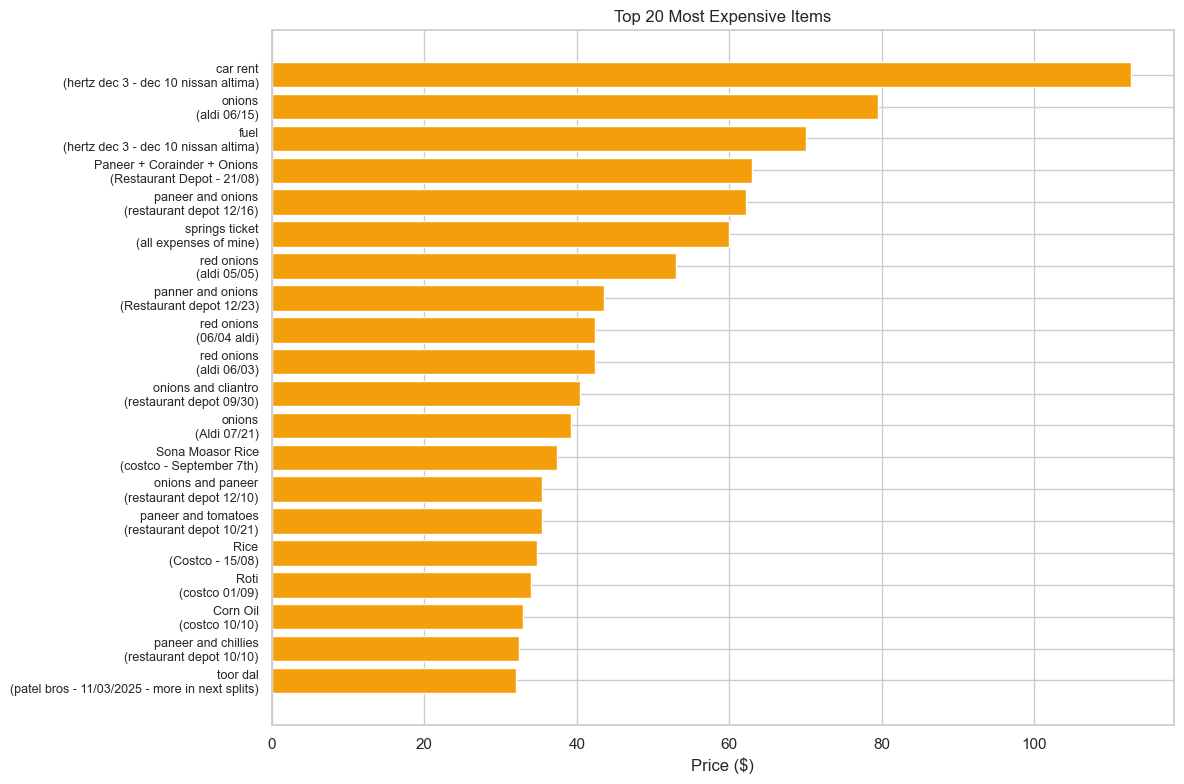

In [9]:
if not items_df.empty:
    top_items = items_df.nlargest(20, "item_price")
    fig, ax = plt.subplots(figsize=(12, 8))
    labels = [f"{row['item_name']}\n({row['description']})" for _, row in top_items.iterrows()]
    ax.barh(range(len(top_items)), top_items["item_price"].values, color="#f59e0b")
    ax.set_yticks(range(len(top_items)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Price ($)")
    ax.set_title("Top 20 Most Expensive Items")
    plt.tight_layout()
    plt.show()
else:
    print("No item data available.")

## Most Frequently Ordered Items

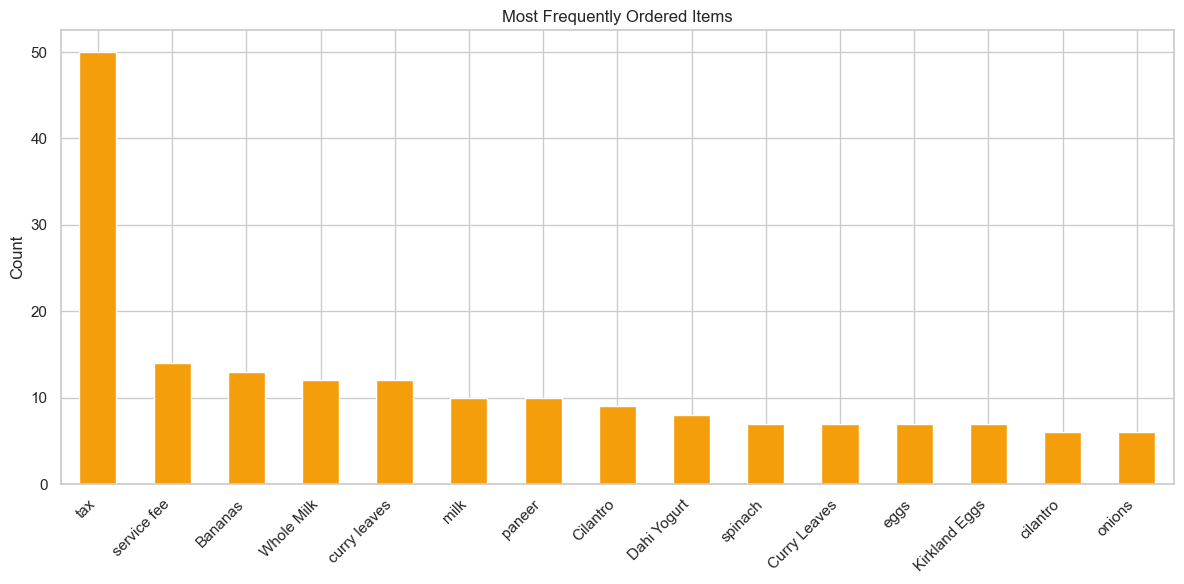

In [10]:
if not items_df.empty:
    freq = items_df["item_name"].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 6))
    freq.plot(kind="bar", ax=ax, color="#f59e0b", edgecolor="white")
    ax.set_title("Most Frequently Ordered Items")
    ax.set_ylabel("Count")
    ax.set_xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No item data available.")

## Item Preferences by Member

Visualize which members tend to purchase which items, based on the canonical preferences in `member_preferences.json`.

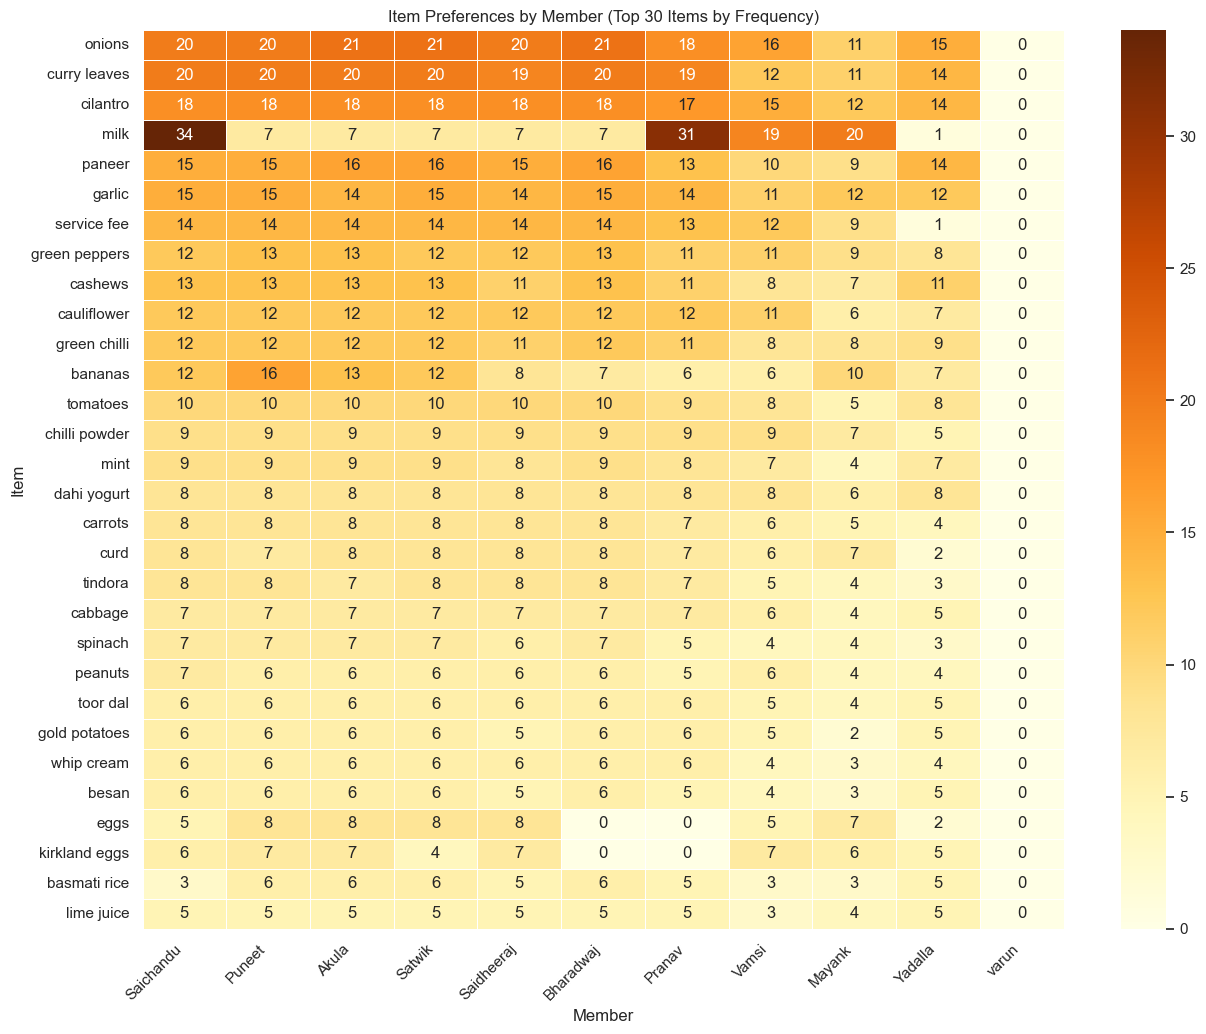


Loaded 414 canonical items across 12 members


In [11]:
# Load member preferences (canonical item -> member purchase counts)
prefs_path = Path("../backend/data/member_preferences.json")
with open(prefs_path) as f:
    prefs = json.load(f)

# Build a DataFrame: rows = items, columns = members, values = purchase counts
rows = {}
for item_name, item_data in prefs.items():
    if item_name.startswith("__"):  # skip __SHARED__ etc.
        continue
    rows[item_name] = item_data["members"]

prefs_df = pd.DataFrame(rows).T.fillna(0).astype(int)
prefs_df.index.name = "item"

# Select top 30 items by total appearances
prefs_df["_total"] = prefs_df.sum(axis=1)
top_items_df = prefs_df.nlargest(30, "_total").drop(columns=["_total"])

# Sort columns by total purchases (most active members first)
col_order = top_items_df.sum().sort_values(ascending=False).index
top_items_df = top_items_df[col_order]

fig, ax = plt.subplots(figsize=(max(12, len(top_items_df.columns) * 1.2), max(8, len(top_items_df) * 0.35)))
sns.heatmap(top_items_df, annot=True, fmt="d", cmap="YlOrBr", linewidths=0.5, ax=ax)
ax.set_title("Item Preferences by Member (Top 30 Items by Frequency)")
ax.set_ylabel("Item")
ax.set_xlabel("Member")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nLoaded {len(prefs_df)} canonical items across {len(prefs_df.columns)} members")

In [12]:
# Per-member top items summary
all_members_pref = sorted(prefs_df.columns, key=lambda m: prefs_df[m].sum(), reverse=True)

for member in all_members_pref:
    member_items = prefs_df[member].sort_values(ascending=False)
    member_items = member_items[member_items > 0].head(10)
    if member_items.empty:
        continue
    print(f"{'=' * 40}")
    print(f"  {member} — Top {len(member_items)} Items")
    print(f"{'=' * 40}")
    for item_name, count in member_items.items():
        bar = "█" * int(count)
        print(f"  {item_name:<25s} {count:>3d}  {bar}")
    print()

  _total — Top 10 Items
  onions                    183  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  curry leaves              175  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  cilantro                  166  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  milk                      140  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  paneer                    139  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  g